In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
marketing = pd.read_csv("marketing_campaign_dataset.csv")

In [5]:
marketing.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [6]:
marketing.shape

(200000, 16)

In [7]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [8]:
marketing.columns

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement_Score', 'Customer_Segment', 'Date'],
      dtype='object')

# Data Cleaning

In [9]:
marketing.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [10]:
marketing.duplicated().sum()

0

In [11]:
marketing['Date'] = pd.to_datetime(marketing['Date'])

In [12]:
marketing['Acquisition_Cost'] = marketing['Acquisition_Cost'].str.replace('$', '')
marketing['Acquisition_Cost'] = marketing['Acquisition_Cost'].str.replace(',', '')
marketing['Acquisition_Cost']=marketing['Acquisition_Cost'].astype(float)

In [13]:
marketing.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score,Date
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000
mean,100000.500000,0.080070,12504.393040,5.002438,549.772030,5507.301520,5.494710,2021-07-01 23:35:09.600000
min,1.000000,0.010000,5000.000000,2.000000,100.000000,1000.000000,1.000000,2021-01-01 00:00:00
25%,50000.750000,0.050000,8739.750000,3.500000,325.000000,3266.000000,3.000000,2021-04-02 00:00:00
50%,100000.500000,0.080000,12496.500000,5.010000,550.000000,5517.500000,5.000000,2021-07-02 00:00:00
75%,150000.250000,0.120000,16264.000000,6.510000,775.000000,7753.000000,8.000000,2021-10-01 00:00:00
max,200000.000000,0.150000,20000.000000,8.000000,1000.000000,10000.000000,10.000000,2021-12-31 00:00:00
std,57735.171256,0.040602,4337.664545,1.734488,260.019056,2596.864286,2.872581,NaN


In [14]:
marketing['Customer_Segment'].nunique()

5

In [15]:
marketing['Campaign_Type'].value_counts()

Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64

# EDA

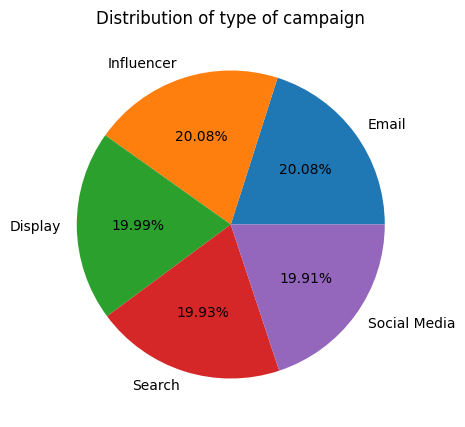

In [16]:
plt.figure(figsize=(5, 5))
plt.pie(marketing['Campaign_Type'].value_counts(), labels=marketing['Campaign_Type'].unique(),
        autopct='%1.2f%%')
plt.title("Distribution of type of campaign")
plt.show()

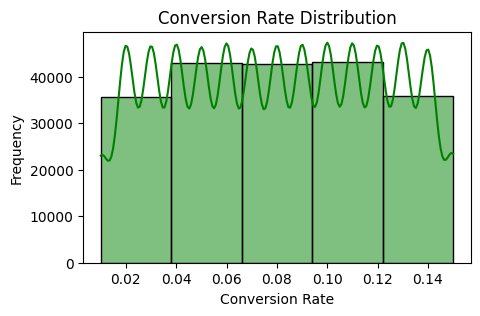

In [17]:
plt.figure(figsize=(5, 3))
sns.histplot(data=marketing, x='Conversion_Rate', bins=5, kde=True, color='Green')
plt.title('Conversion Rate Distribution')
plt.xlabel('Conversion Rate')
plt.ylabel('Frequency')
plt.show()

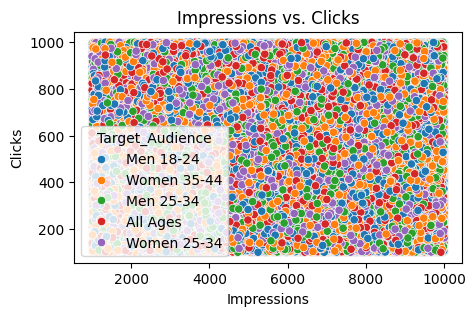

In [18]:
plt.figure(figsize=(5, 3))
sns.scatterplot(data=marketing, y='Clicks', x='Impressions', hue='Target_Audience')
plt.title('Impressions vs. Clicks')
plt.xlabel('Impressions')
plt.ylabel('Clicks')
plt.show()

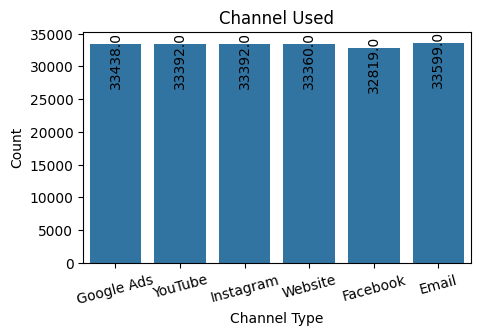

In [19]:
plt.figure(figsize=(5,3))
ax=sns.countplot(data=marketing, x='Channel_Used')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center_baseline', xytext=(0, 5), textcoords='offset points', rotation=90)
plt.title('Channel Used')
plt.xticks(rotation=15)
plt.xlabel('Channel Type')
plt.ylabel('Count')
plt.show()

In [20]:
plt.figure(figsize=(7,7))
sns.heatmap(marketing.corr(), vmax =1.0, fmt='0.2f', square = True, annot = True,cmap='plasma' )
plt.title('Correlation Heatmap',fontsize=15)
plt.show()

ValueError: could not convert string to float: 'Innovate Industries'

<Figure size 700x700 with 0 Axes>

In [21]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  object        
 2   Campaign_Type     200000 non-null  object        
 3   Target_Audience   200000 non-null  object        
 4   Duration          200000 non-null  object        
 5   Channel_Used      200000 non-null  object        
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  float64       
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  object        
 10  Language          200000 non-null  object        
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Cust

In [22]:
marketing.columns

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement_Score', 'Customer_Segment', 'Date'],
      dtype='object')

In [23]:
marketing['Duration'] = marketing['Duration'].str.replace(' days', '').astype(int)

In [24]:
labencd = LabelEncoder()

In [25]:
marketing['Company']= labencd.fit_transform(marketing['Company'])

In [26]:
marketing['Campaign_Type']= labencd.fit_transform(marketing['Campaign_Type'])

In [27]:
marketing['Target_Audience']= labencd.fit_transform(marketing['Target_Audience'])

In [28]:
marketing['Channel_Used']= labencd.fit_transform(marketing['Channel_Used'])

In [29]:
marketing['Customer_Segment']= labencd.fit_transform(marketing['Customer_Segment'])

In [30]:
X = marketing[['Campaign_Type', 'Target_Audience',  'Channel_Used']]

In [31]:
y = marketing['Conversion_Rate']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)

## Random Forest Regressor

In [33]:
rf_regressor = RandomForestRegressor(random_state=33)
rf_regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=33)

In [34]:
rf_predictions = rf_regressor.predict(X_test)

In [35]:
rf_mse = mean_squared_error(y_test, rf_predictions)

In [36]:
print("Random Forest Mean Squared Error:", rf_mse)

Random Forest Mean Squared Error: 0.001645681943628543


In [37]:
rf_r2 = r2_score(y_test, rf_predictions)

In [38]:
print("Random Forest R-squared Score:", rf_r2)

Random Forest R-squared Score: -0.0011398904148685052


## Decision Tree Regressor

In [41]:
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [42]:
dt_predictions = dt_regressor.predict(X_test)

In [43]:
dt_mse = mean_squared_error(y_test, dt_predictions)

In [44]:
print("Decision Tree Mean Squared Error:", dt_mse)

Decision Tree Mean Squared Error: 0.0016456695077535016


In [45]:
dt_r2 = r2_score(y_test, dt_predictions)

In [46]:
print("Decision Tree R-squared Score:", dt_r2)

Decision Tree R-squared Score: -0.0011323251312944649


# Linear Regression

In [47]:
lr_regressor = LinearRegression()
lr_regressor.fit(X_train, y_train)

LinearRegression()

In [48]:
lr_predictions = lr_regressor.predict(X_test)

In [49]:
lr_mse = mean_squared_error(y_test, lr_predictions)

In [50]:
print("Linear Regression Mean Squared Error:", lr_mse)

Linear Regression Mean Squared Error: 0.0016438863960373034


In [51]:
lr_r2 = r2_score(y_test, lr_predictions)

In [52]:
print("Linear Regression R-squared Score:", lr_r2)

Linear Regression R-squared Score: -4.758073395594309e-05


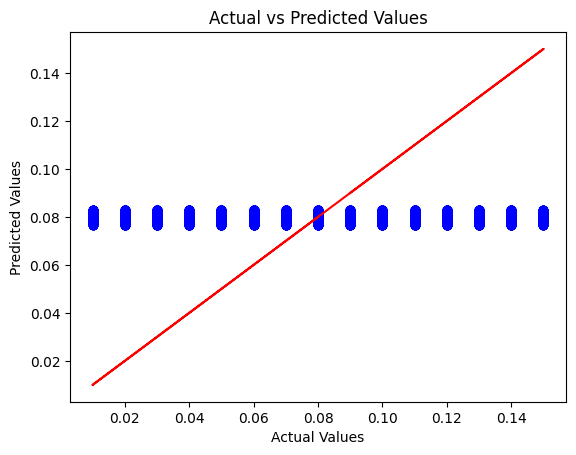

In [56]:
# Plotting actual vs predicted values
plt.scatter(y_test, rf_predictions, color='blue')
plt.plot(y_test, y_test, color='red')
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()